# 判断为什么P=0

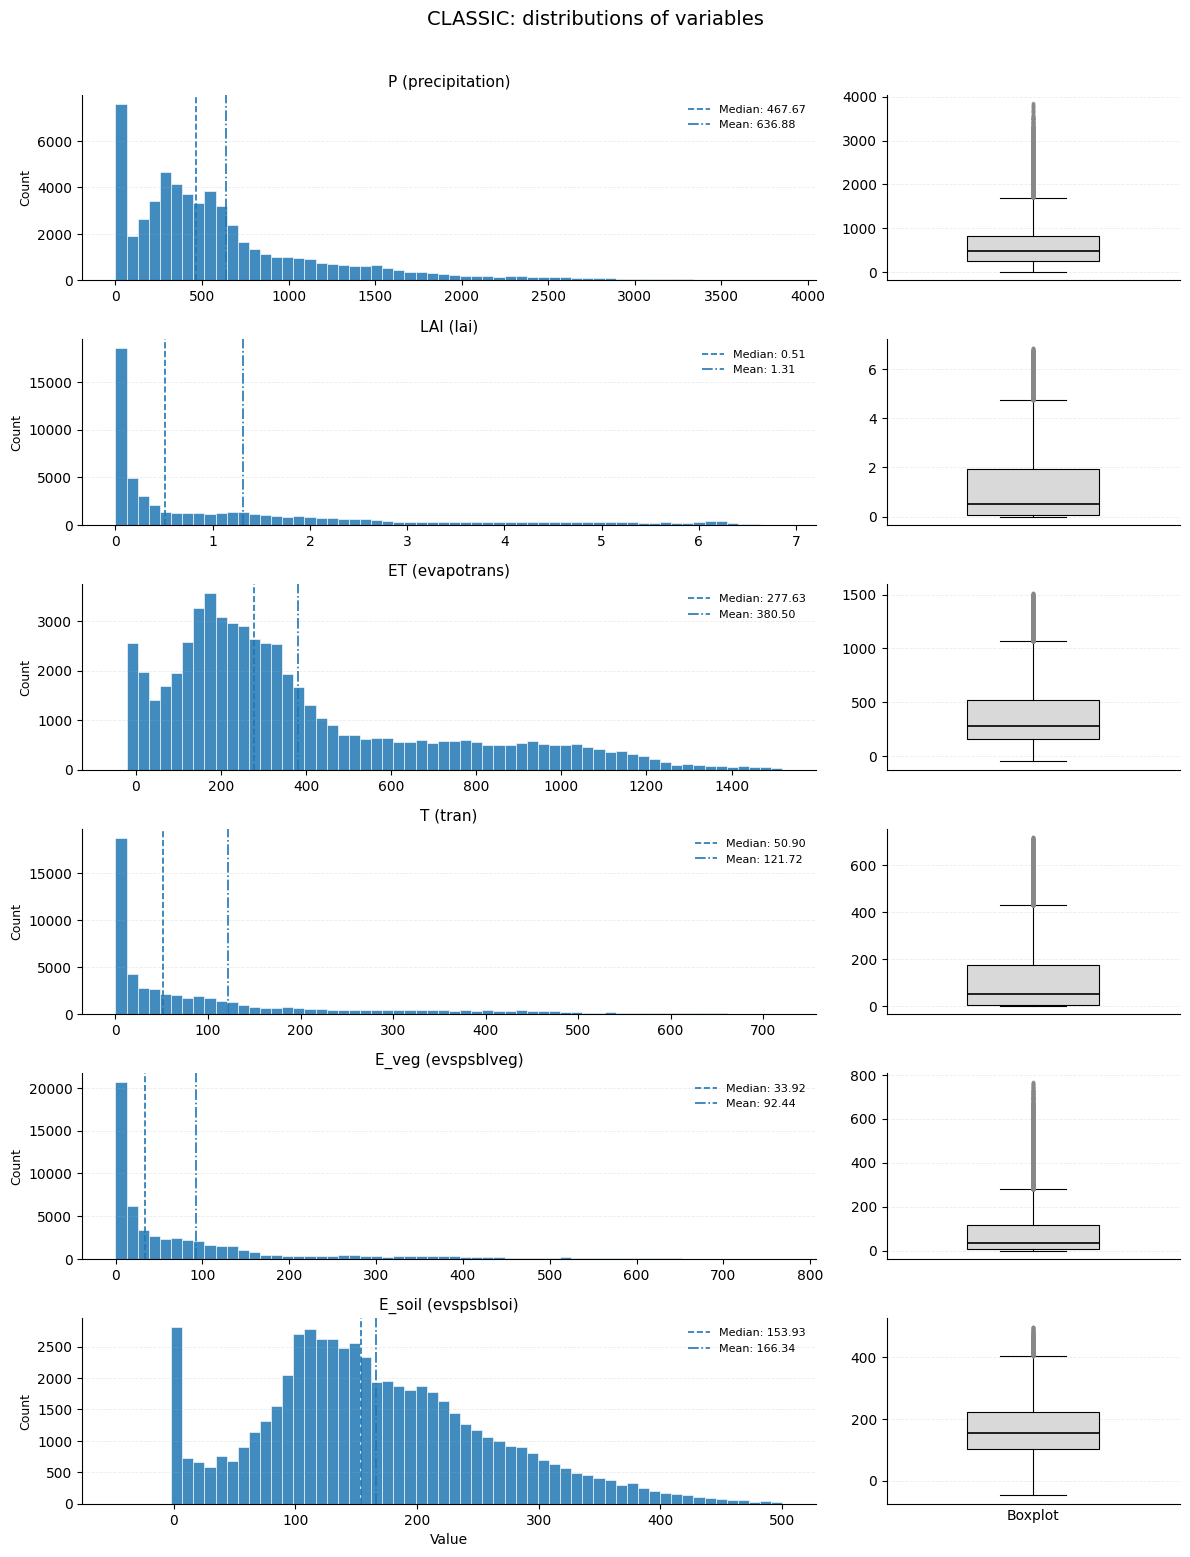

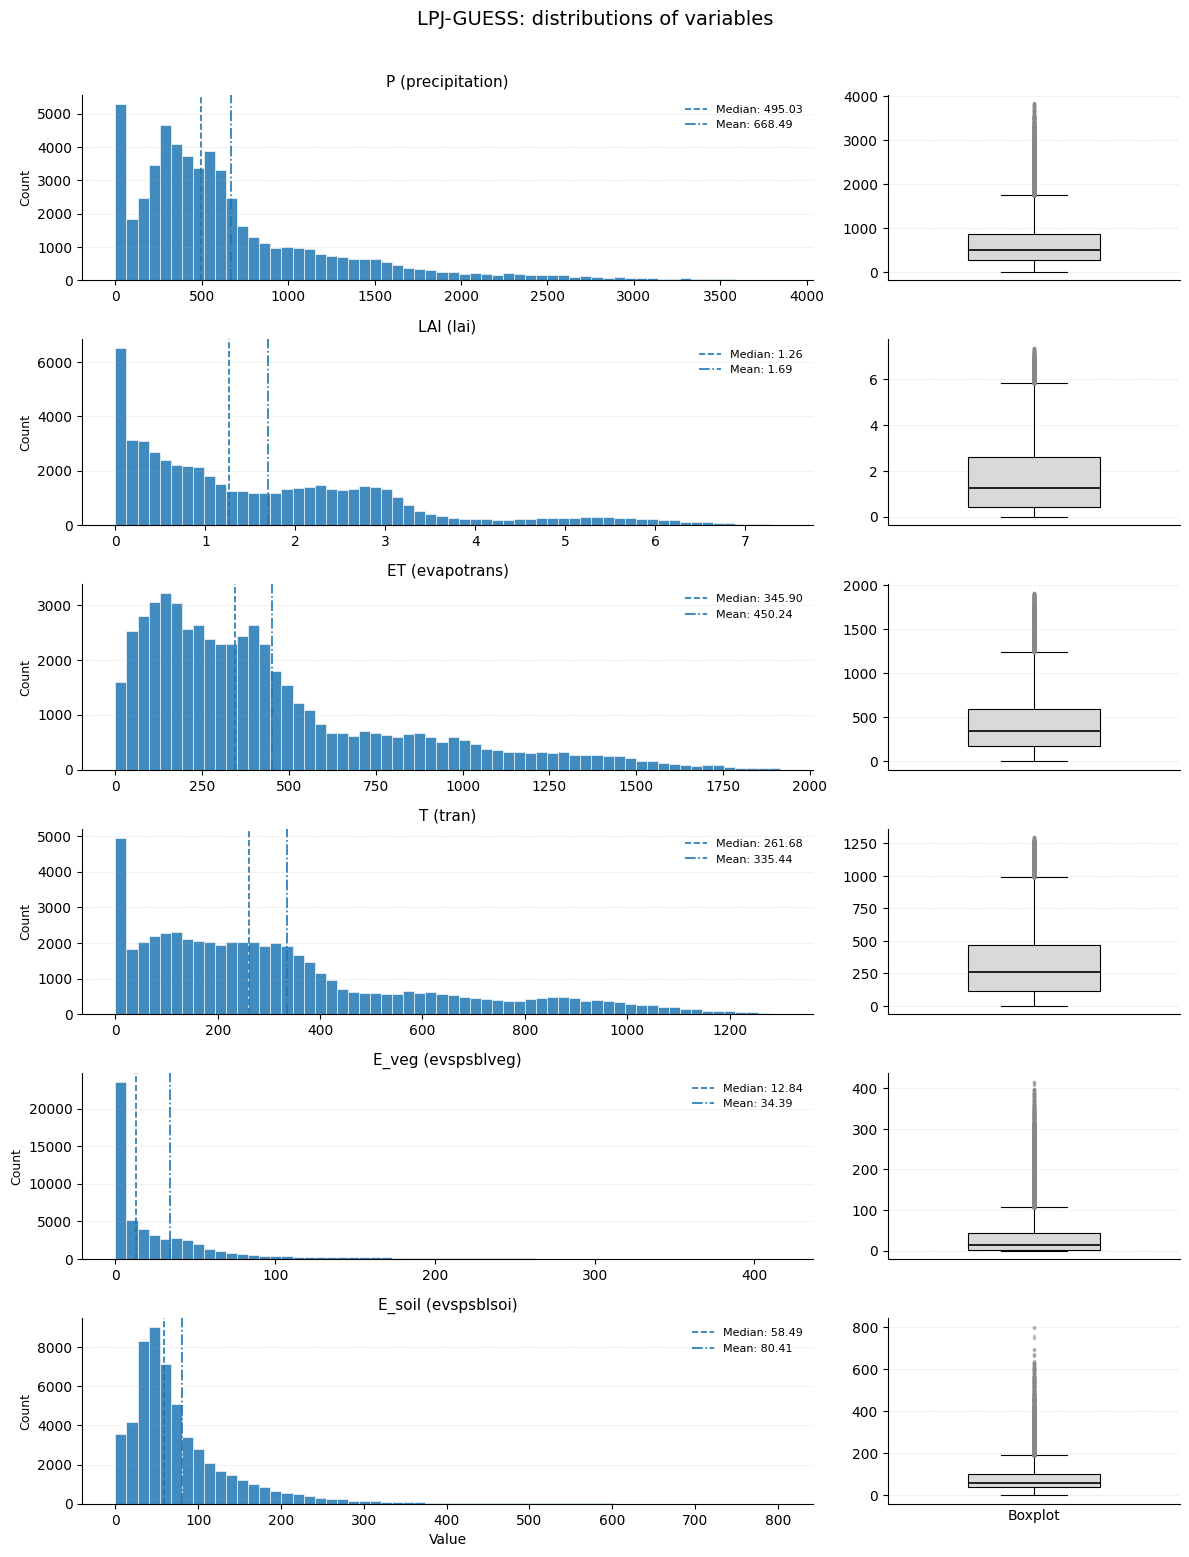

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. 读取数据
data_dir = Path("./data/preprocessed/preprocessed_with_zones")

classic_df = pd.read_csv(data_dir / "classic_with_climate_zones_filtered_30yr_mean.csv")
lpj_df = pd.read_csv(data_dir / "lpj_guess_with_climate_zones_filtered_30yr_mean.csv")

# 2. 变量映射
var_map = {
    "P": "precipitation",
    "LAI": "lai",
    "ET": "evapotrans",
    "T": "tran",
    "E_veg": "evspsblveg",
    "E_soil": "evspsblsoi"
}

# 3. 绘图函数
def plot_hist_box(df, model_name, bins=50):
    n_vars = len(var_map)
    fig, axes = plt.subplots(
        n_vars, 2,
        figsize=(12, 2.6 * n_vars),
        gridspec_kw={"width_ratios": [4, 1.6]}
    )

    if n_vars == 1:
        axes = np.array([axes])

    fig.patch.set_facecolor("white")

    for i, (label, col) in enumerate(var_map.items()):
        values = df[col].dropna().values

        ax_hist = axes[i, 0]
        ax_box = axes[i, 1]

        ax_hist.hist(
            values,
            bins=bins,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.5
        )
        ax_hist.set_title(f"{label} ({col})", fontsize=11, pad=6)
        ax_hist.set_ylabel("Count", fontsize=9)
        ax_hist.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
        ax_hist.spines["top"].set_visible(False)
        ax_hist.spines["right"].set_visible(False)

        median_val = np.median(values)
        mean_val = np.mean(values)
        ax_hist.axvline(median_val, linestyle="--", linewidth=1.2, label=f"Median: {median_val:.2f}")
        ax_hist.axvline(mean_val, linestyle="-.", linewidth=1.2, label=f"Mean: {mean_val:.2f}")
        ax_hist.legend(fontsize=8, frameon=False)

        ax_box.boxplot(
            values,
            vert=True,
            patch_artist=True,
            widths=0.45,
            boxprops=dict(facecolor="#d9d9d9", edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.2),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=2.5,
                markerfacecolor="#888888",
                markeredgecolor="none",
                alpha=0.5
            )
        )
        ax_box.set_xticks([])
        ax_box.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
        ax_box.spines["top"].set_visible(False)
        ax_box.spines["right"].set_visible(False)

    axes[-1, 0].set_xlabel("Value", fontsize=10)
    axes[-1, 1].set_xlabel("Boxplot", fontsize=10)

    fig.suptitle(f"{model_name}: distributions of variables", fontsize=14, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

# 4. 显示图
plot_hist_box(classic_df, "CLASSIC", bins=60)
plot_hist_box(lpj_df, "LPJ-GUESS", bins=60)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. 读取数据
data_dir = Path("./data/preprocessed/preprocessed_with_zones")

classic_raw = pd.read_csv(data_dir / "classic_with_climate_zones_filtered_30yr_mean.csv")
lpj_raw = pd.read_csv(data_dir / "lpj_guess_with_climate_zones_filtered_30yr_mean.csv")

print("CLASSIC raw:", classic_raw.shape)
print("LPJ-GUESS raw:", lpj_raw.shape)
print("\nColumns:")
print(classic_raw.columns.tolist())

CLASSIC raw: (58293, 10)
LPJ-GUESS raw: (55966, 10)

Columns:
['lat', 'lon', 'precipitation', 'lai', 'evapotrans', 'tran', 'evspsblveg', 'evspsblsoi', 'climate_zone', 'is_outlier']


In [27]:
# 严格等于 0
classic_p0 = classic_raw[classic_raw["precipitation"] == 0].copy()
lpj_p0 = lpj_raw[lpj_raw["precipitation"] == 0].copy()

print("CLASSIC precipitation == 0")
print(f"  count: {len(classic_p0):,}")
print(f"  percentage: {len(classic_p0) / len(classic_raw) * 100:.2f}%")

print("\nLPJ-GUESS precipitation == 0")
print(f"  count: {len(lpj_p0):,}")
print(f"  percentage: {len(lpj_p0) / len(lpj_raw) * 100:.2f}%")

print("\nCLASSIC climate zones for P=0:")
print(classic_p0["climate_zone"].value_counts(dropna=False))

print("\nLPJ-GUESS climate zones for P=0:")
print(lpj_p0["climate_zone"].value_counts(dropna=False))

CLASSIC precipitation == 0
  count: 3,927
  percentage: 6.74%

LPJ-GUESS precipitation == 0
  count: 1,653
  percentage: 2.95%

CLASSIC climate zones for P=0:
climate_zone
CD         3124
CW          584
HW          180
Unknown      39
Name: count, dtype: int64

LPJ-GUESS climate zones for P=0:
climate_zone
CW         564
CD         520
HW         241
Unknown    218
HD         110
Name: count, dtype: int64


In [28]:
# 接近 0 的版本
eps = 1e-12

classic_p0_near = classic_raw[np.isclose(classic_raw["precipitation"], 0, atol=eps)].copy()
lpj_p0_near = lpj_raw[np.isclose(lpj_raw["precipitation"], 0, atol=eps)].copy()

print("CLASSIC precipitation ~ 0")
print(f"  count: {len(classic_p0_near):,}")

print("LPJ-GUESS precipitation ~ 0")
print(f"  count: {len(lpj_p0_near):,}")

CLASSIC precipitation ~ 0
  count: 3,927
LPJ-GUESS precipitation ~ 0
  count: 1,653


In [29]:
print("CLASSIC examples:")
display(classic_p0.head(20))

print("LPJ-GUESS examples:")
display(lpj_p0.head(20))

CLASSIC examples:


,lat,lon,precipitation,lai,evapotrans,tran,evspsblveg,evspsblsoi,climate_zone,is_outlier
22,-53.75,-67.75,0.0,0.640363,216.49661,40.131634,39.367516,136.99747,CD,False
23,-53.25,-71.75,0.0,1.010053,487.70236,55.334354,136.482600,295.88538,CD,False
52,-51.25,-72.75,0.0,0.968333,556.41394,59.018898,120.608300,376.78674,CW,False
67,-50.25,-72.25,0.0,0.410552,377.99960,51.833828,29.942827,296.22296,CD,False
75,-49.75,-72.25,0.0,0.401226,370.62598,49.594387,25.549004,295.48264,CD,False
145,-46.75,-72.75,0.0,0.968211,478.03613,53.747350,86.810520,337.47824,CW,False
168,-46.25,167.25,0.0,0.991405,595.58966,51.464040,168.777470,375.34814,CW,False
190,-45.25,-73.25,0.0,1.164162,480.91373,69.865620,82.932495,328.11563,CW,False
202,-45.25,167.75,0.0,1.252055,551.44434,58.442730,154.070340,338.93130,CW,False
207,-44.75,-73.75,0.0,1.538680,439.93015,70.637370,91.504410,277.78840,CW,False


LPJ-GUESS examples:


,lat,lon,precipitation,lai,evapotrans,tran,evspsblveg,evspsblsoi,climate_zone,is_outlier
9,-54.25,-69.75,0.0,1.301071,364.95900,189.208150,8.837341,166.914340,CD,False
16,-53.75,-70.75,0.0,0.600199,268.31726,90.334590,2.427477,175.555280,CD,False
21,-53.75,-67.75,0.0,0.805514,240.69658,123.640040,2.990716,114.065430,CD,False
27,-53.25,-68.25,0.0,0.819857,260.28000,131.661120,3.534197,125.085500,Unknown,False
29,-52.75,-70.75,0.0,1.632880,358.11030,240.043820,10.079266,107.987305,CD,False
31,-52.75,-69.75,0.0,1.350604,307.62418,201.108030,7.029252,99.486440,CD,False
38,-52.25,-69.25,0.0,0.808384,257.72183,128.167370,3.571272,125.984474,CD,False
46,-51.75,-60.25,0.0,1.249054,298.29126,169.078340,5.426070,123.788330,CW,False
51,-51.25,-72.75,0.0,2.492057,722.88470,472.681240,60.962290,189.241560,CW,False
58,-51.25,-59.75,0.0,0.703040,287.48972,109.927284,3.230425,174.332340,CW,False


In [30]:
def plot_zero_precip_points(df_zero, model_name, point_color="#D95F5F", point_size=3, alpha=0.7):
    fig = plt.figure(figsize=(12, 6), dpi=180)
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#F5F5F5", edgecolor="none", zorder=0)
    ax.coastlines(linewidth=0.4, color="black", zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="black", zorder=2)

    ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.3,
        color="0.75",
        alpha=0.6,
        linestyle="-",
        zorder=1
    )

    ax.scatter(
        df_zero["lon"],
        df_zero["lat"],
        s=point_size,
        color=point_color,
        alpha=alpha,
        linewidth=0,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    ax.set_title(f"{model_name}: spatial distribution of samples with P = 0", fontsize=12, pad=8)
    plt.show()

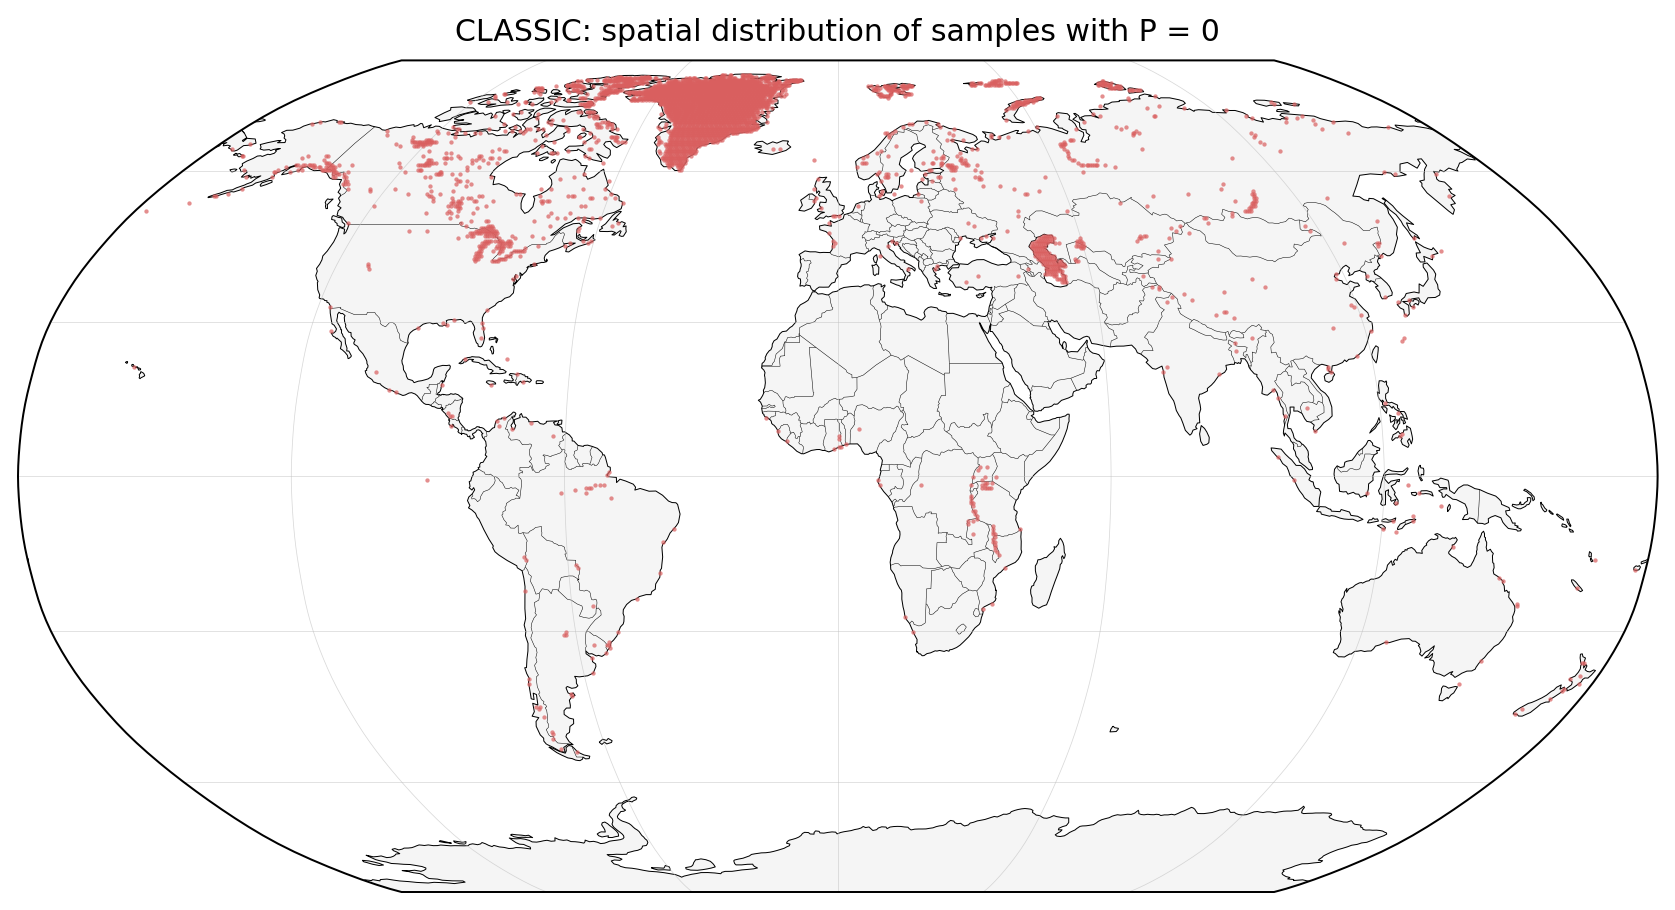

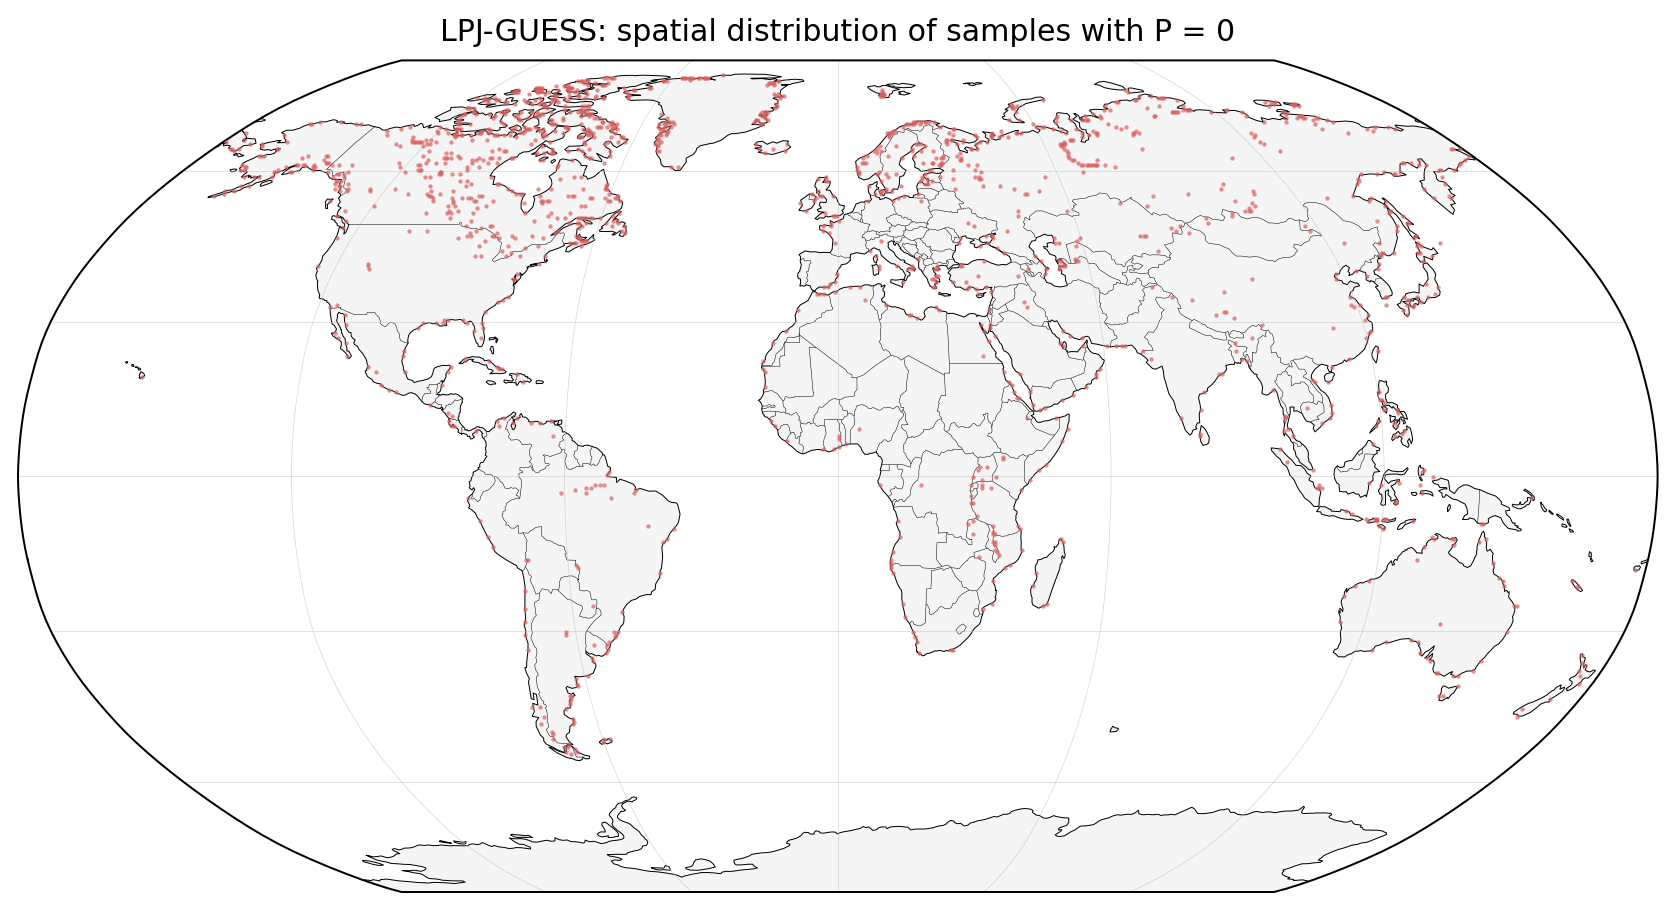

In [31]:
plot_zero_precip_points(classic_p0, "CLASSIC")
plot_zero_precip_points(lpj_p0, "LPJ-GUESS")

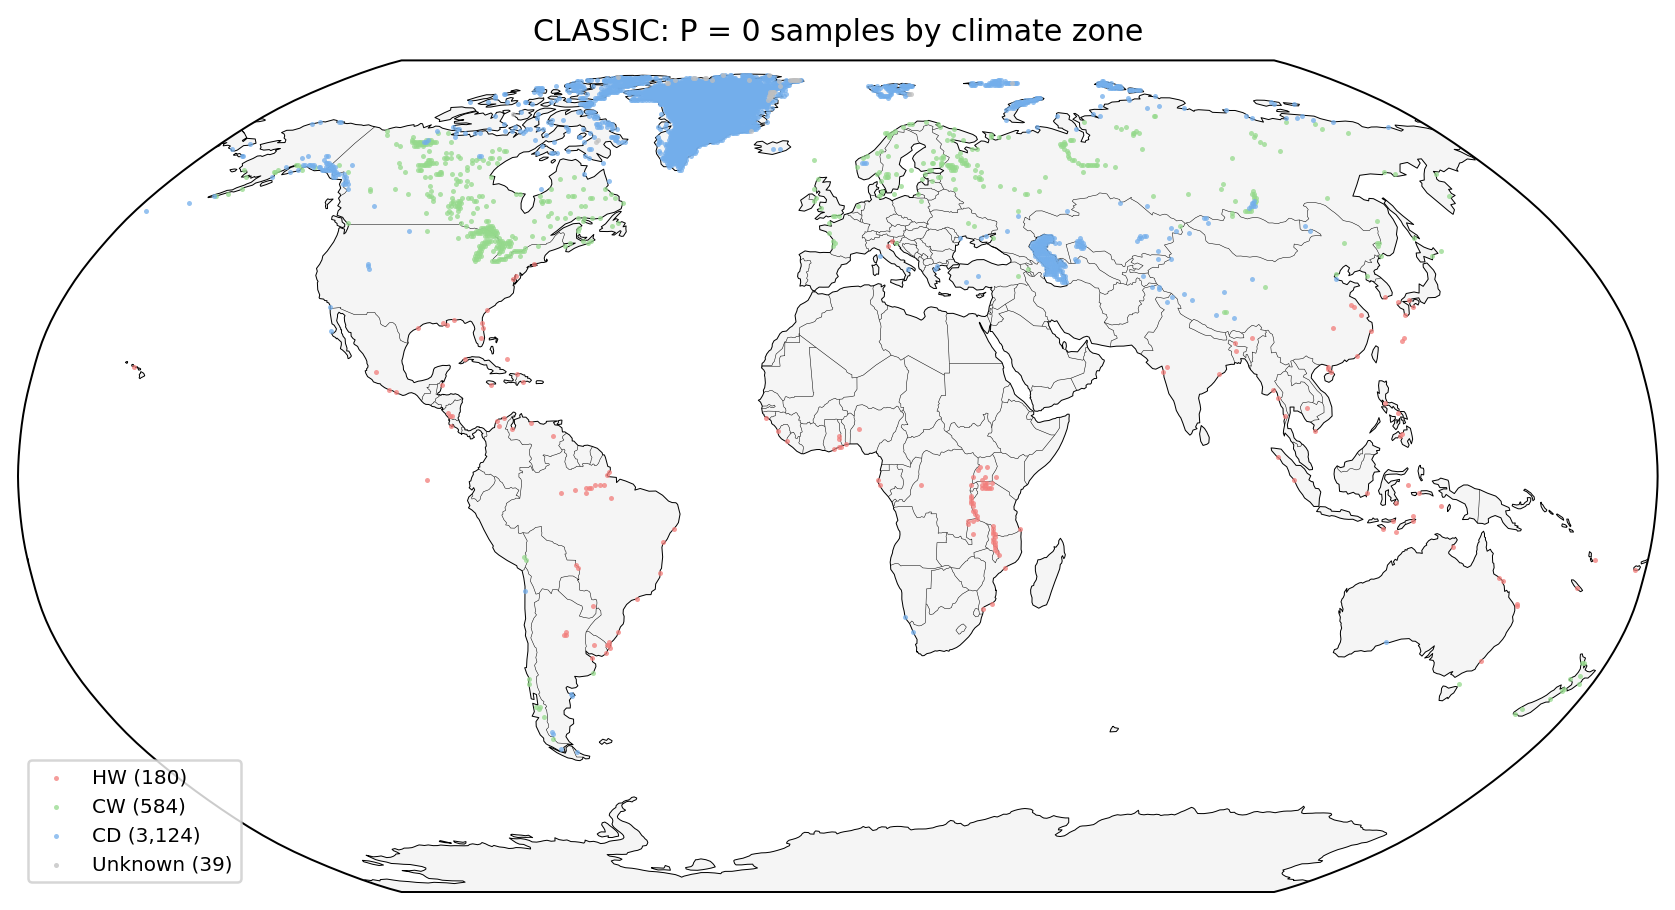

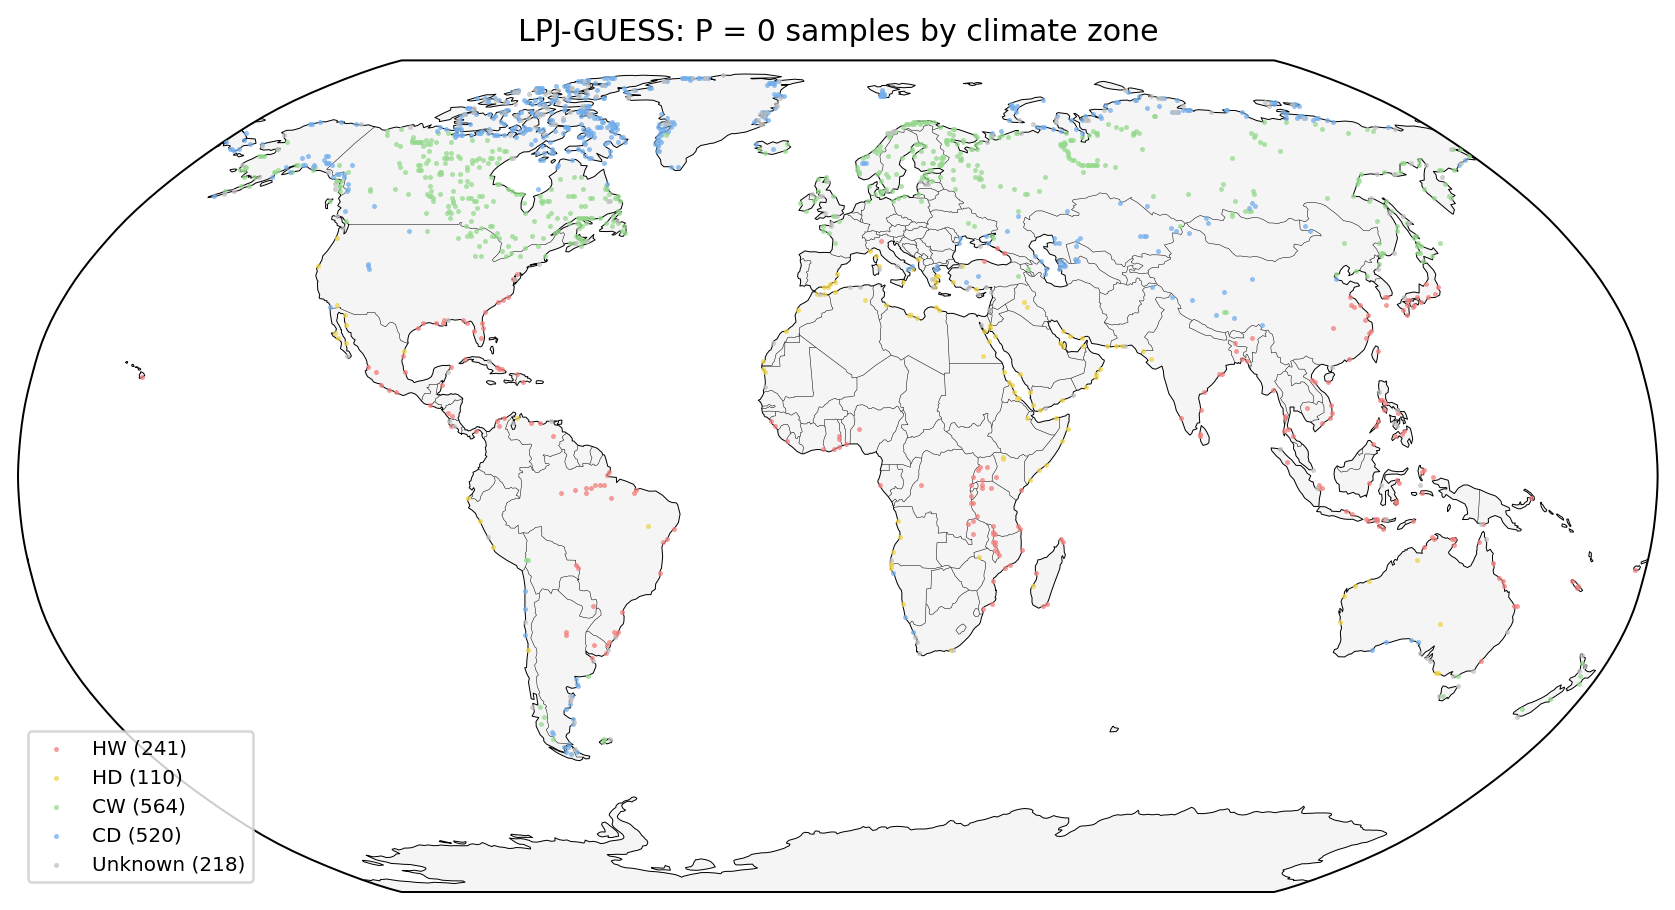

In [32]:
def plot_zero_precip_points_by_zone(df_zero, model_name, point_size=4, alpha=0.75):
    zone_colors = {
        "HW": "#F27D7A",
        "HD": "#EFD447",
        "CW": "#95D98C",
        "CD": "#73AEEB",
        "Unknown": "#BFBFBF"
    }

    fig = plt.figure(figsize=(12, 6), dpi=180)
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#F5F5F5", edgecolor="none", zorder=0)
    ax.coastlines(linewidth=0.4, color="black", zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="black", zorder=2)

    for zone in ["HW", "HD", "CW", "CD", "Unknown"]:
        sub = df_zero[df_zero["climate_zone"] == zone]
        if len(sub) == 0:
            continue

        ax.scatter(
            sub["lon"],
            sub["lat"],
            s=point_size,
            color=zone_colors[zone],
            alpha=alpha,
            linewidth=0,
            transform=ccrs.PlateCarree(),
            label=f"{zone} ({len(sub):,})",
            zorder=3
        )

    ax.legend(loc="lower left", fontsize=8, frameon=True)
    ax.set_title(f"{model_name}: P = 0 samples by climate zone", fontsize=12, pad=8)
    plt.show()


plot_zero_precip_points_by_zone(classic_p0, "CLASSIC")
plot_zero_precip_points_by_zone(lpj_p0, "LPJ-GUESS")

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# 1. 读取数据
data_dir = Path("./data/preprocessed/preprocessed_with_zones")

classic_df = pd.read_csv(data_dir / "classic_with_climate_zones_filtered_30yr_mean.csv")
lpj_df = pd.read_csv(data_dir / "lpj_guess_with_climate_zones_filtered_30yr_mean.csv")

print("CLASSIC:", classic_df.shape)
print("LPJ-GUESS:", lpj_df.shape)
print("\nColumns:")
print(classic_df.columns.tolist())

CLASSIC: (58293, 10)
LPJ-GUESS: (55966, 10)

Columns:
['lat', 'lon', 'precipitation', 'lai', 'evapotrans', 'tran', 'evspsblveg', 'evspsblsoi', 'climate_zone', 'is_outlier']


In [46]:
classic_p0 = classic_df[classic_df["precipitation"] == 0].copy()
lpj_p0 = lpj_df[lpj_df["precipitation"] == 0].copy()

print("CLASSIC P=0:", len(classic_p0))
print("LPJ-GUESS P=0:", len(lpj_p0))

print("\nCLASSIC P=0 examples:")
print(classic_p0.head())

print("\nLPJ-GUESS P=0 examples:")
print(lpj_p0.head())

CLASSIC P=0: 3927
LPJ-GUESS P=0: 1653

CLASSIC P=0 examples:
      lat    lon  precipitation       lai  evapotrans       tran  evspsblveg  \
22 -53.75 -67.75            0.0  0.640363   216.49661  40.131634   39.367516   
23 -53.25 -71.75            0.0  1.010053   487.70236  55.334354  136.482600   
52 -51.25 -72.75            0.0  0.968333   556.41394  59.018898  120.608300   
67 -50.25 -72.25            0.0  0.410552   377.99960  51.833828   29.942827   
75 -49.75 -72.25            0.0  0.401226   370.62598  49.594387   25.549004   

    evspsblsoi climate_zone  is_outlier  
22   136.99747           CD       False  
23   295.88538           CD       False  
52   376.78674           CW       False  
67   296.22296           CD       False  
75   295.48264           CD       False  

LPJ-GUESS P=0 examples:
      lat    lon  precipitation       lai  evapotrans       tran  evspsblveg  \
9  -54.25 -69.75            0.0  1.301071   364.95900  189.20815    8.837341   
16 -53.75 -70.75     

In [47]:
lakes_path = Path("./data/water_area/ne_10m_lakes/ne_10m_lakes.shp")

lakes = gpd.read_file(lakes_path)
print(lakes.head())
print(lakes.crs)
print("Number of lake polygons:", len(lakes))

  featurecla  scalerank                   name            name_abb  \
0       Lake          9                Eğirdir             Egridir   
1       Lake          7               Beyşehir            Beysehir   
2       Lake          5               Engozero            Engozero   
3       Lake          4               Pääjärvi            Paajarvi   
4       Lake          9  Ozero Pitlyarskiy Sor  O. Pitlyarskiy Sor   

                   name_alt  note                           delta dam_name  \
0                      None  None  New or modified in version 1.2     None   
1                      None  None  New or modified in version 1.2     None   
2                      None  None  New or modified in version 1.2     None   
3  Lake Pya, Ozero Pjaozero  None  New or modified in version 1.2     None   
4      Lake Pitlyarskiy Sor  None  New or modified in version 1.2     None   

   year admin  ...                name_tr             name_vi   name_zh  \
0   -99  None  ...                E

In [48]:
if lakes.crs is not None:
    lakes = lakes.to_crs(epsg=4326)

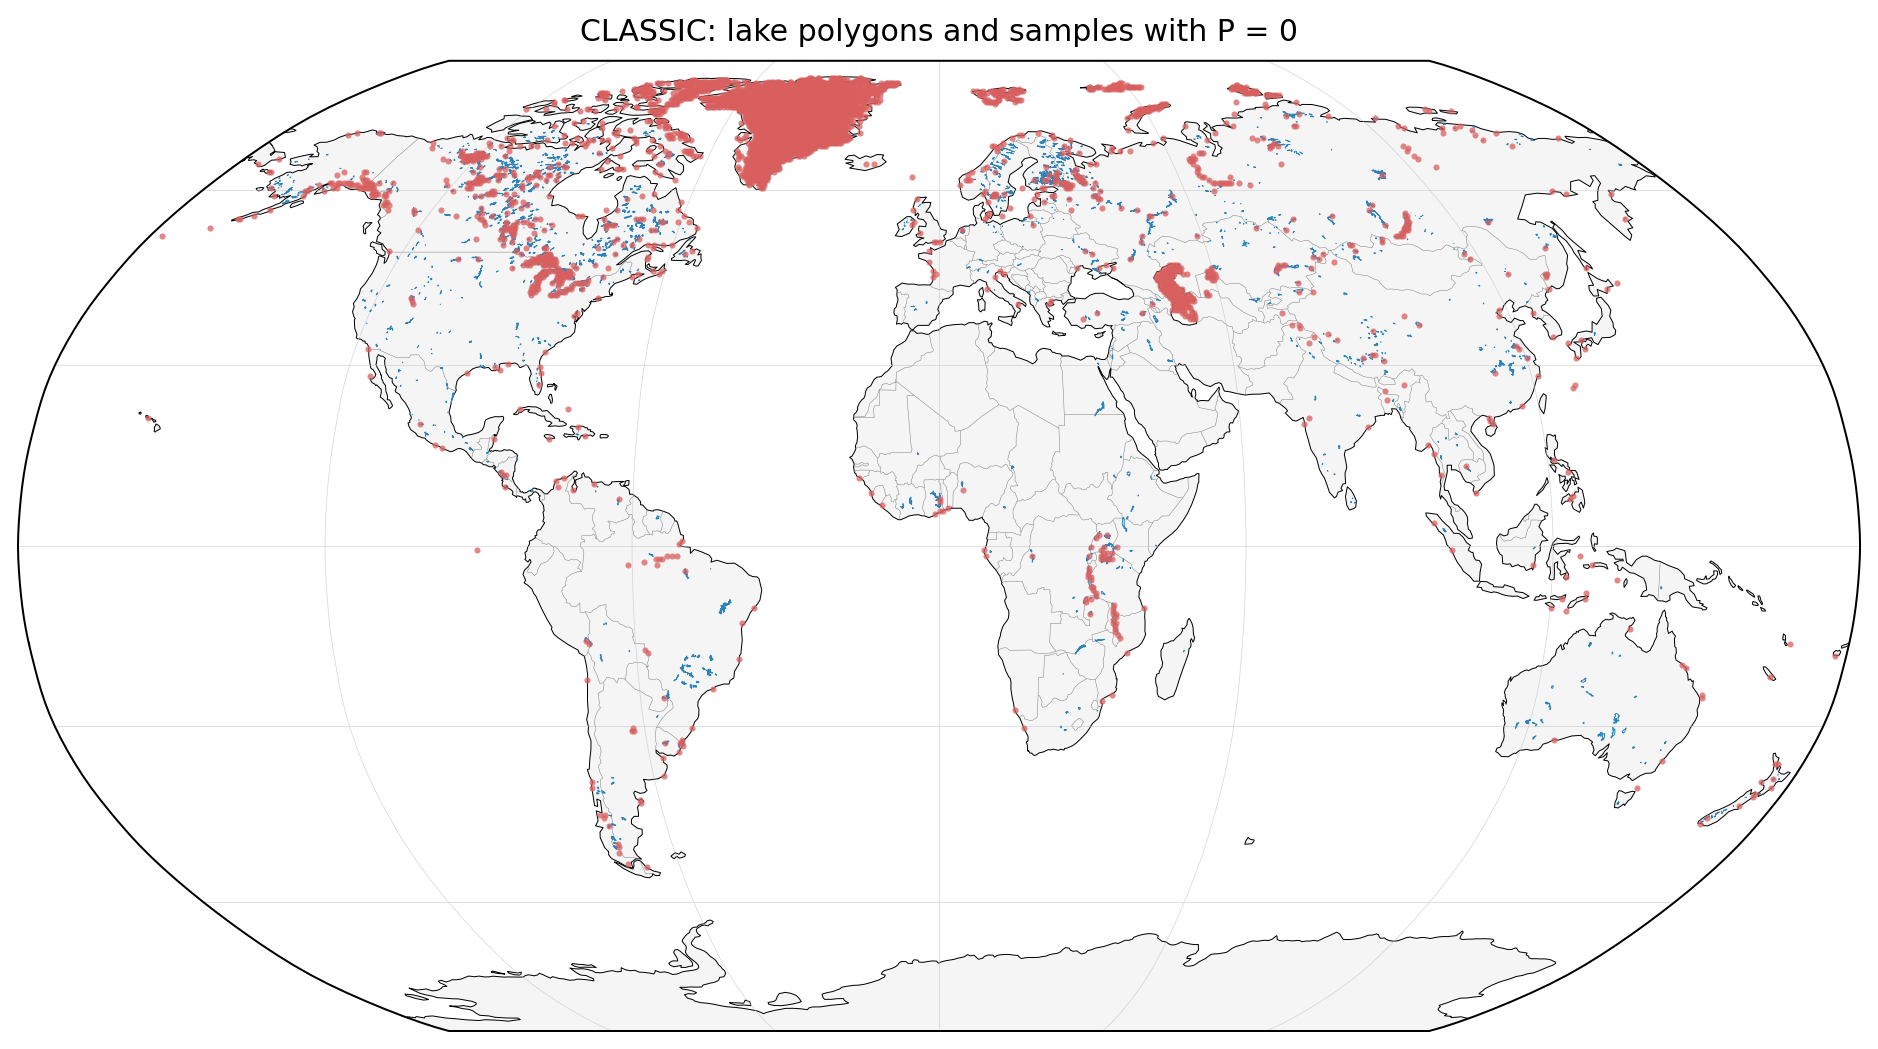

In [49]:
fig = plt.figure(figsize=(14, 7), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.3,
    color="0.75",
    alpha=0.6,
    linestyle="-",
    zorder=1
)

# 湖泊轮廓
lakes.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#2B83BA",
    linewidth=0.35,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# P=0 点
ax.scatter(
    classic_p0["lon"],
    classic_p0["lat"],
    s=6,
    color="#D95F5F",
    alpha=0.75,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.set_title("CLASSIC: lake polygons and samples with P = 0", fontsize=12, pad=8)
plt.show()

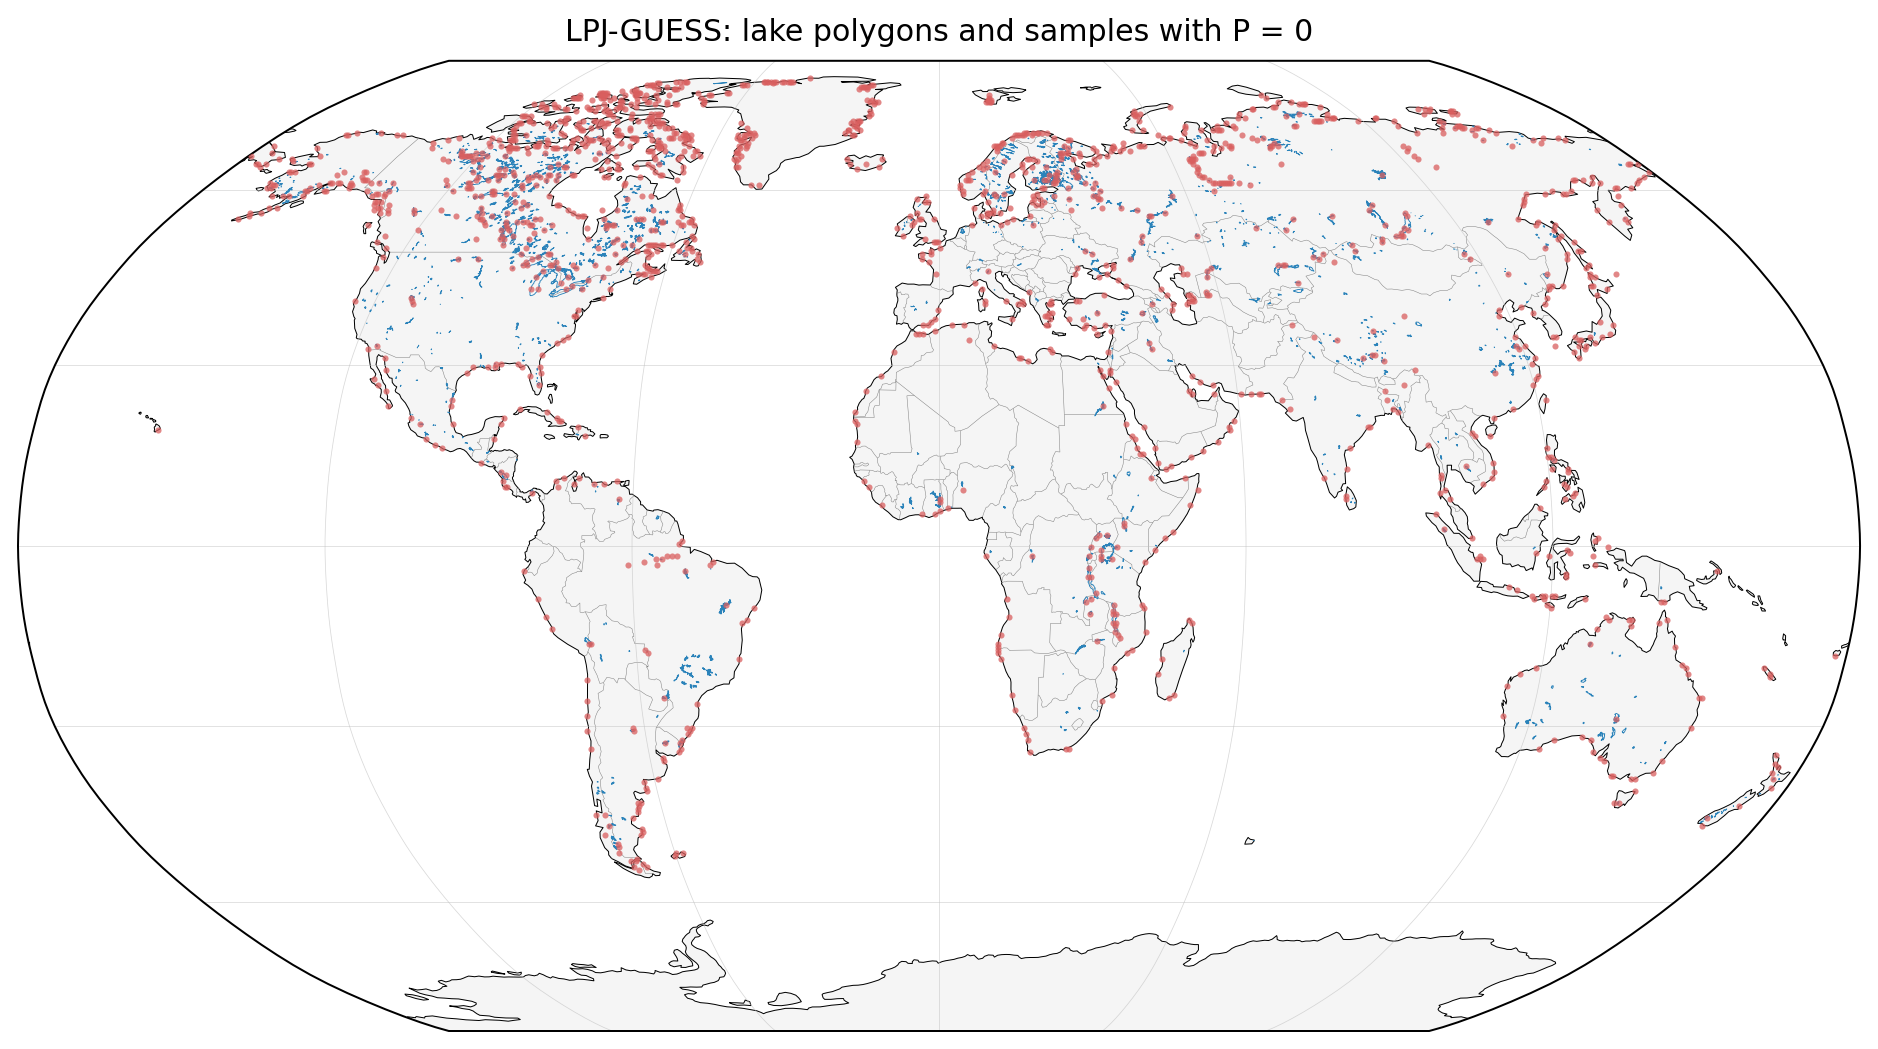

In [50]:
fig = plt.figure(figsize=(14, 7), dpi=180)
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax.coastlines(linewidth=0.4, color="black", zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.3,
    color="0.75",
    alpha=0.6,
    linestyle="-",
    zorder=1
)

# 湖泊轮廓
lakes.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#2B83BA",
    linewidth=0.35,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# P=0 点
ax.scatter(
    lpj_p0["lon"],
    lpj_p0["lat"],
    s=6,
    color="#D95F5F",
    alpha=0.75,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.set_title("LPJ-GUESS: lake polygons and samples with P = 0", fontsize=12, pad=8)
plt.show()

In [51]:
classic_p0_gdf = gpd.GeoDataFrame(
    classic_p0.copy(),
    geometry=gpd.points_from_xy(classic_p0["lon"], classic_p0["lat"]),
    crs="EPSG:4326"
)

lpj_p0_gdf = gpd.GeoDataFrame(
    lpj_p0.copy(),
    geometry=gpd.points_from_xy(lpj_p0["lon"], lpj_p0["lat"]),
    crs="EPSG:4326"
)

print("CLASSIC P=0 GeoDataFrame:", classic_p0_gdf.shape)
print("LPJ-GUESS P=0 GeoDataFrame:", lpj_p0_gdf.shape)

CLASSIC P=0 GeoDataFrame: (3927, 11)
LPJ-GUESS P=0 GeoDataFrame: (1653, 11)


In [57]:
def quantify_overlap_with_lakes(points_gdf, lakes_gdf, model_name):
    # 空间连接：找出落在湖泊 polygon 内的点
    joined = gpd.sjoin(
        points_gdf,
        lakes_gdf,
        how="left",
        predicate="within"
        # predicate="intersects"

    )

    # 如果 join 成功，index_right 非空表示该点落在某个湖泊 polygon 内
    inside_mask = joined["index_right"].notna()

    n_total = len(joined)
    n_inside = inside_mask.sum()
    ratio = n_inside / n_total * 100 if n_total > 0 else 0

    print(f"\n{model_name}")
    print("-" * 50)
    print(f"Total P=0 points: {n_total:,}")
    print(f"Points inside lake polygons: {n_inside:,}")
    print(f"Overlap ratio: {ratio:.2f}%")

    return joined, inside_mask

classic_joined, classic_inside_mask = quantify_overlap_with_lakes(
    classic_p0_gdf, lakes, "CLASSIC"
)

lpj_joined, lpj_inside_mask = quantify_overlap_with_lakes(
    lpj_p0_gdf, lakes, "LPJ-GUESS"
)


CLASSIC
--------------------------------------------------
Total P=0 points: 3,938
Points inside lake polygons: 499
Overlap ratio: 12.67%

LPJ-GUESS
--------------------------------------------------
Total P=0 points: 1,655
Points inside lake polygons: 297
Overlap ratio: 17.95%


In [58]:
classic_inside = classic_joined[classic_inside_mask].copy()
classic_outside = classic_joined[~classic_inside_mask].copy()

lpj_inside = lpj_joined[lpj_inside_mask].copy()
lpj_outside = lpj_joined[~lpj_inside_mask].copy()

print("CLASSIC inside lakes:", len(classic_inside))
print("CLASSIC outside lakes:", len(classic_outside))

print("LPJ-GUESS inside lakes:", len(lpj_inside))
print("LPJ-GUESS outside lakes:", len(lpj_outside))

CLASSIC inside lakes: 499
CLASSIC outside lakes: 3439
LPJ-GUESS inside lakes: 297
LPJ-GUESS outside lakes: 1358


In [54]:
print("CLASSIC P=0 points inside lakes:")
print(classic_inside[["lat", "lon", "precipitation"]].head(20))

print("\nLPJ-GUESS P=0 points inside lakes:")
print(lpj_inside[["lat", "lon", "precipitation"]].head(20))

CLASSIC P=0 points inside lakes:
        lat     lon  precipitation
67   -50.25  -72.25            0.0
75   -49.75  -72.25            0.0
145  -46.75  -72.75            0.0
503  -38.75  175.75            0.0
1247 -32.75  -56.25            0.0
1253 -32.75  -53.25            0.0
1254 -32.75  -52.75            0.0
1367 -32.25  -52.75            0.0
1733 -30.75  -62.75            0.0
1734 -30.75  -62.25            0.0
3378 -25.25  -55.25            0.0
6347 -16.25  -69.25            0.0
6505 -15.75  -69.75            0.0
7069 -14.25   34.75            0.0
7209 -13.75   34.75            0.0
7346 -13.25   34.75            0.0
7482 -12.75   34.75            0.0
7618 -12.25   34.25            0.0
7753 -11.75   34.75            0.0
7874 -11.25   29.75            0.0

LPJ-GUESS P=0 points inside lakes:
        lat     lon  precipitation
66   -50.25  -72.25            0.0
74   -49.75  -72.25            0.0
143  -46.75  -72.75            0.0
297  -42.75  146.25            0.0
498  -38.75  175.75  

In [59]:
print("CLASSIC P=0 points with lat > 60:", (classic_p0["lat"] > 60).sum())
print("LPJ-GUESS P=0 points with lat > 60:", (lpj_p0["lat"] > 60).sum())

CLASSIC P=0 points with lat > 60: 3124
LPJ-GUESS P=0 points with lat > 60: 776


In [60]:
print(classic_p0["climate_zone"].value_counts(dropna=False))
print(lpj_p0["climate_zone"].value_counts(dropna=False))

climate_zone
CD         3124
CW          584
HW          180
Unknown      39
Name: count, dtype: int64
climate_zone
CW         564
CD         520
HW         241
Unknown    218
HD         110
Name: count, dtype: int64


In [ ]:
classic_outside = classic_joined[~classic_inside_mask].copy()
lpj_outside = lpj_joined[~lpj_inside_mask].copy()

print("CLASSIC outside lakes:", len(classic_outside))
print("LPJ-GUESS outside lakes:", len(lpj_outside))

In [61]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_outside_lake_p0(df_outside, model_name, point_color="#D95F5F", point_size=6, alpha=0.75):
    fig = plt.figure(figsize=(12, 6), dpi=180)
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
    ax.coastlines(linewidth=0.4, color="black", zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="gray", zorder=1)

    ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.3,
        color="0.75",
        alpha=0.6,
        linestyle="-",
        zorder=1
    )

    ax.scatter(
        df_outside["lon"],
        df_outside["lat"],
        s=point_size,
        color=point_color,
        alpha=alpha,
        linewidth=0,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    ax.set_title(f"{model_name}: P = 0 points outside lake polygons", fontsize=12, pad=8)
    plt.show()

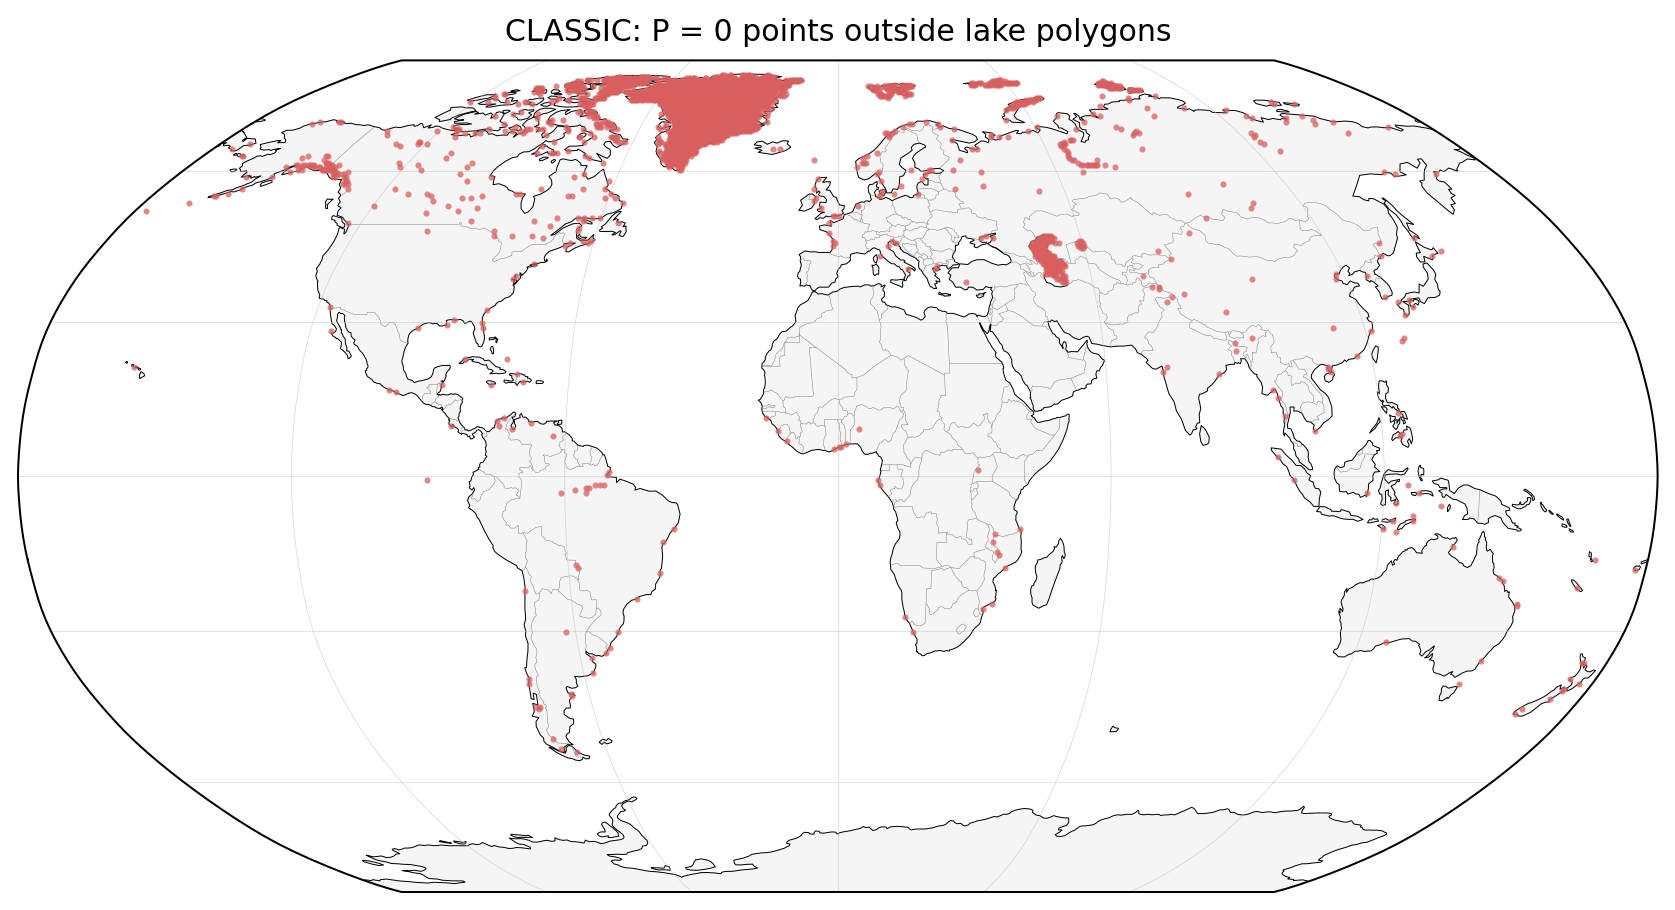

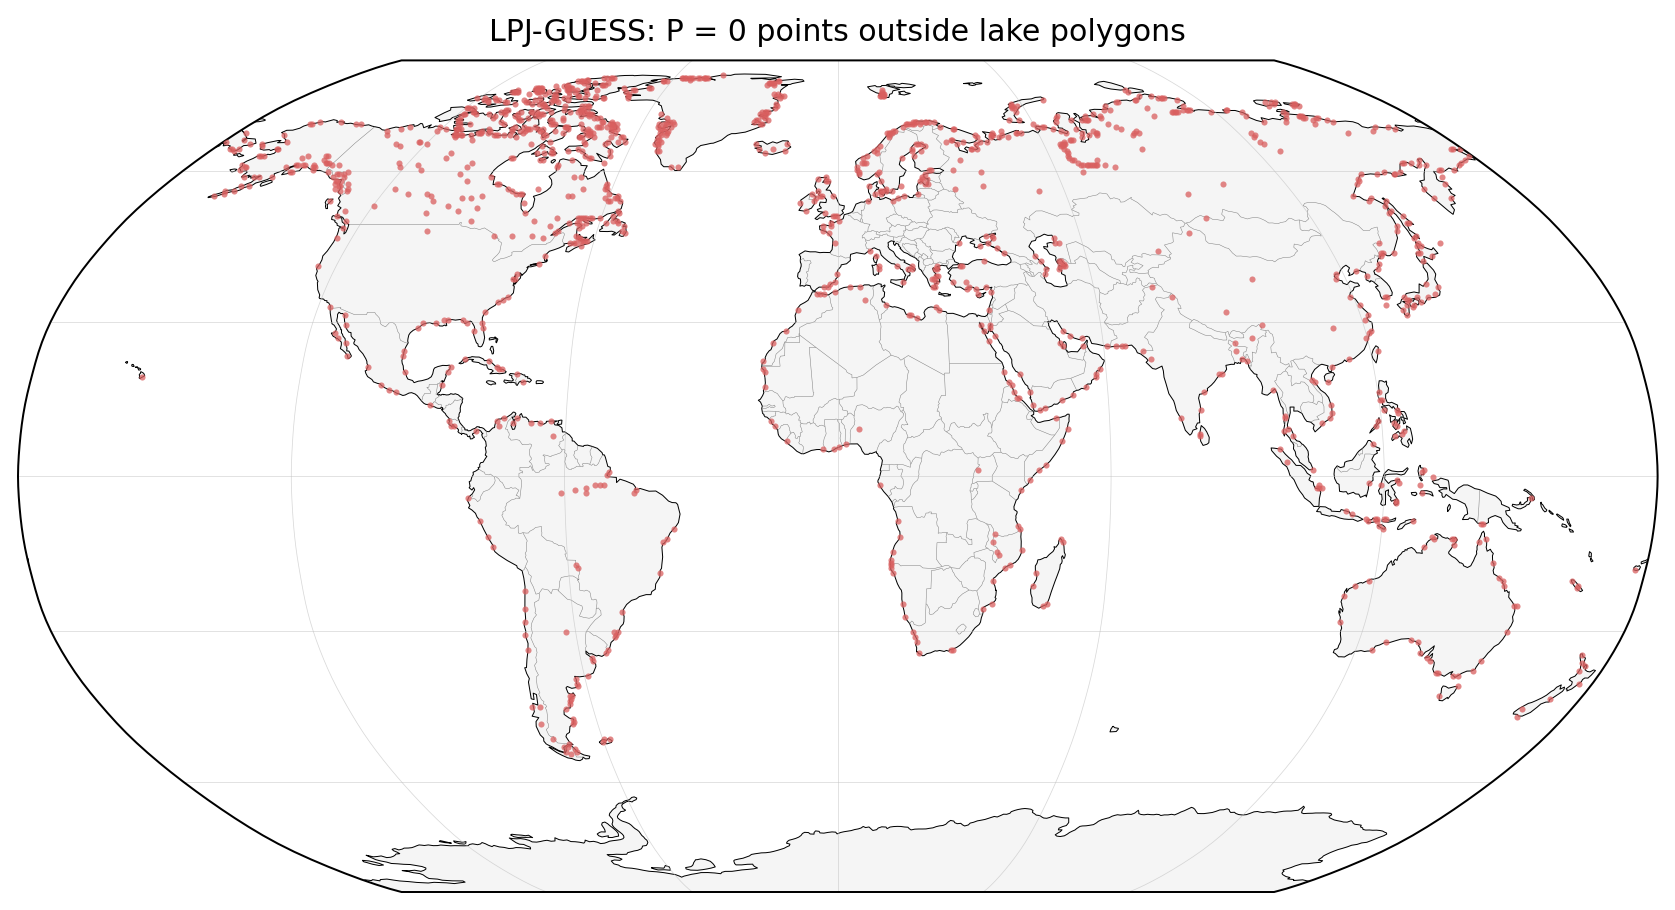

In [62]:
plot_outside_lake_p0(classic_outside, "CLASSIC")
plot_outside_lake_p0(lpj_outside, "LPJ-GUESS")

# 计算冰盖和lake的比例

In [63]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

# 1. 读取 30 年平均数据
data_dir = Path("./data/preprocessed/preprocessed_with_zones")

classic_df = pd.read_csv(data_dir / "classic_with_climate_zones_filtered_30yr_mean.csv")
lpj_df = pd.read_csv(data_dir / "lpj_guess_with_climate_zones_filtered_30yr_mean.csv")

# 2. 读取 lakes shapefile
lakes_path = Path("./data/water_area/ne_10m_lakes/ne_10m_lakes.shp")
lakes = gpd.read_file(lakes_path)

# 3. 读取 glaciated areas shapefile
glacier_path = Path("./data/water_area/ne_10m_glaciated_areas/ne_10m_glaciated_areas.shp")
glaciers = gpd.read_file(glacier_path)

# 统一坐标系
if lakes.crs is not None:
    lakes = lakes.to_crs(epsg=4326)

if glaciers.crs is not None:
    glaciers = glaciers.to_crs(epsg=4326)

print("CLASSIC:", classic_df.shape)
print("LPJ-GUESS:", lpj_df.shape)
print("Lakes polygons:", len(lakes))
print("Glacier polygons:", len(glaciers))

CLASSIC: (58293, 10)
LPJ-GUESS: (55966, 10)
Lakes polygons: 1355
Glacier polygons: 1886


In [64]:
classic_p0 = classic_df[classic_df["precipitation"] == 0].copy()
lpj_p0 = lpj_df[lpj_df["precipitation"] == 0].copy()

classic_p0_gdf = gpd.GeoDataFrame(
    classic_p0.copy(),
    geometry=gpd.points_from_xy(classic_p0["lon"], classic_p0["lat"]),
    crs="EPSG:4326"
)

lpj_p0_gdf = gpd.GeoDataFrame(
    lpj_p0.copy(),
    geometry=gpd.points_from_xy(lpj_p0["lon"], lpj_p0["lat"]),
    crs="EPSG:4326"
)

print("CLASSIC P=0:", len(classic_p0_gdf))
print("LPJ-GUESS P=0:", len(lpj_p0_gdf))

CLASSIC P=0: 3927
LPJ-GUESS P=0: 1653


In [68]:
def classify_p0_points(points_gdf, lakes_gdf, glaciers_gdf):
    # 保留原始索引
    points = points_gdf.copy()

    # 和 lakes 做空间连接
    join_lakes = gpd.sjoin(
        points[["geometry"]],
        lakes_gdf,
        how="left",
        predicate="intersects"
    )

    # 哪些原始点至少匹配到一个 lake polygon
    lake_idx = join_lakes.loc[join_lakes["index_right"].notna()].index.unique()

    # 和 glaciers 做空间连接
    join_glaciers = gpd.sjoin(
        points[["geometry"]],
        glaciers_gdf,
        how="left",
        predicate="intersects"
    )

    # 哪些原始点至少匹配到一个 glacier polygon
    glacier_idx = join_glaciers.loc[join_glaciers["index_right"].notna()].index.unique()

    # 回填到原始点表
    result = points.copy()
    result["in_lake"] = result.index.isin(lake_idx)
    result["in_glacier"] = result.index.isin(glacier_idx)

    result["category"] = "neither"
    result.loc[result["in_lake"] & ~result["in_glacier"], "category"] = "lake_only"
    result.loc[~result["in_lake"] & result["in_glacier"], "category"] = "glacier_only"
    result.loc[result["in_lake"] & result["in_glacier"], "category"] = "both"

    return result

In [69]:
classic_classified = classify_p0_points(classic_p0_gdf, lakes, glaciers)
lpj_classified = classify_p0_points(lpj_p0_gdf, lakes, glaciers)

In [70]:
def summarize_categories(df, model_name):
    counts = df["category"].value_counts(dropna=False)
    ratios = (df["category"].value_counts(normalize=True, dropna=False) * 100).round(2)

    print(f"\n{model_name}")
    print("-" * 60)
    print("Counts:")
    print(counts)

    print("\nRatios (%):")
    print(ratios)

    print("\nDetailed summary:")
    total = len(df)
    for cat in ["lake_only", "glacier_only", "both", "neither"]:
        n = (df["category"] == cat).sum()
        pct = n / total * 100 if total > 0 else 0
        print(f"  {cat}: {n:,} ({pct:.2f}%)")

summarize_categories(classic_classified, "CLASSIC")
summarize_categories(lpj_classified, "LPJ-GUESS")


CLASSIC
------------------------------------------------------------
Counts:
category
glacier_only    2517
neither          922
lake_only        488
Name: count, dtype: int64

Ratios (%):
category
glacier_only    64.09
neither         23.48
lake_only       12.43
Name: proportion, dtype: float64

Detailed summary:
  lake_only: 488 (12.43%)
  glacier_only: 2,517 (64.09%)
  both: 0 (0.00%)
  neither: 922 (23.48%)

LPJ-GUESS
------------------------------------------------------------
Counts:
category
neither         1287
lake_only        295
glacier_only      71
Name: count, dtype: int64

Ratios (%):
category
neither         77.86
lake_only       17.85
glacier_only     4.30
Name: proportion, dtype: float64

Detailed summary:
  lake_only: 295 (17.85%)
  glacier_only: 71 (4.30%)
  both: 0 (0.00%)
  neither: 1,287 (77.86%)
